In [2]:
# [setup]
import os
import subprocess
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from google.cloud import bigquery

# --- File paths ---
MOBILE_NO_IRAN_PATH = "data-official/2026-06/mobile_cps0.02_thresh32_recent13_clip0.6/mozaic_daily_forecast.2026-05-13.gm-D.raw.parquet"
MOBILE_PLUS_IRAN_PATH = "data-official/2026-06/mobile_cps0.02_thresh32_recent13_clip0.6/mozaic_daily_forecast.2026-05-13.gm-D.raw.plus_iran.parquet"
DESKTOP_NO_IRAN_PATH = "data-official/2026-06/desktop_cps0.15983_thresh50_recent13_clip0.6/mozaic_daily_forecast.2026-05-13.ld-D.raw.parquet"
DESKTOP_PLUS_IRAN_PATH = "data-official/2026-06/desktop_cps0.15983_thresh50_recent13_clip0.6/mozaic_daily_forecast.2026-05-13.ld-D.raw.plus_iran.parquet"
PREV_FORECAST_DESKTOP_PLUS_IRAN_PATH = "data-official/2026-04/desktop_cps0.15983_thresh32_recent13_clip0.6/mozaic_daily_forecast.2026-04-01.ld-D.raw.plus_iran.parquet"
PREV_FORECAST_DESKTOP_NO_IRAN_PATH = "data-official/2026-04/desktop_cps0.15983_thresh32_recent13_clip0.6/mozaic_daily_forecast.2026-04-01.ld-D.raw.parquet"
PREV_FORECAST_MOBILE_PLUS_IRAN_PATH = "data-official/2026-04/mobile_cps0.02_thresh32_recent13_clip0.6/mozaic_daily_forecast.2026-04-01.gm-D.raw.plus_iran.parquet"
PREV_FORECAST_MOBILE_NO_IRAN_PATH = "data-official/2026-04/mobile_cps0.02_thresh32_recent13_clip0.6/mozaic_daily_forecast.2026-04-01.gm-D.raw.parquet"
ADJUSTMENTS_DIR = "data-official/2026-06/adjustments"

# --- Date constants ---
DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")
FORECAST_START = pd.Timestamp("2026-05-13")
PREV_FORECAST_START = pd.Timestamp("2026-04-01")
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")

# BQ query lookback — need 28 days before DISPLAY_START for MA
BQ_START = "2025-12-04"

# Anchor execution at git root so relative paths work regardless of notebook location
os.chdir(subprocess.run(['git', 'rev-parse', '--show-toplevel'], capture_output=True, text=True).stdout.strip())


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


In [3]:
# [helpers]
def render_adjustment(spec, date_index):
    """Convert a single adjustment spec to net DAU Series for desktop and mobile."""
    idx = pd.DatetimeIndex(date_index)
    desktop = pd.Series(0.0, index=idx)
    mobile = pd.Series(0.0, index=idx)

    if spec["type"] == "linear_ramp":
        start = pd.Timestamp(spec["start_date"])
        anchor = pd.Timestamp(spec["anchor_date"])
        total_days = (anchor - start).days
        elapsed = np.maximum(0, (idx - start).days)
        desktop[:] = spec.get("desktop_dau", 0) * elapsed / total_days
        mobile[:] = spec.get("mobile_dau", 0) * elapsed / total_days

    elif spec["type"] == "step":
        start = pd.Timestamp(spec["start_date"])
        end = pd.Timestamp(spec["end_date"]) if "end_date" in spec else idx[-1]
        mask = (idx >= start) & (idx <= end)
        desktop[mask] = spec.get("desktop_dau", 0)
        mobile[mask] = spec.get("mobile_dau", 0)

    elif spec["type"] == "daily_series":
        for date_str, values in spec["series"].items():
            date = pd.Timestamp(date_str)
            if date in idx:
                loc = idx.get_loc(date)
                desktop.iloc[loc] = values.get("desktop_dau", 0)
                mobile.iloc[loc] = values.get("mobile_dau", 0)

    return {"desktop": desktop, "mobile": mobile}


def load_adjustments(adjustments_dir, date_index):
    """Sum all adjustment components in a directory into net desktop/mobile DAU series."""
    idx = pd.DatetimeIndex(date_index)
    desktop_total = pd.Series(0.0, index=idx)
    mobile_total = pd.Series(0.0, index=idx)
    for path in sorted(glob.glob(f"{adjustments_dir}/*.json")):
        with open(path) as f:
            spec = json.load(f)
        rendered = render_adjustment(spec, idx)
        desktop_total += rendered["desktop"]
        mobile_total += rendered["mobile"]
    return {"desktop": desktop_total, "mobile": mobile_total}


def apply_net_adjustment(ma_series, net_adjustments, platform, forecast_start=None):
    """Apply net adjustment to a 28-day MA series, starting at forecast_start.

    Uses FORECAST_START by default. Pass a different date for prior forecasts whose
    predicted data begins earlier (e.g. PREV_FORECAST_START for the N-1 comparison).
    """
    if forecast_start is None:
        forecast_start = FORECAST_START
    result = ma_series.copy()
    forecast_mask = result.index >= forecast_start
    # Reindex to ma_series dates — desktop and mobile have different date ranges
    adj = net_adjustments[platform].reindex(result.index, fill_value=0.0)
    result[forecast_mask] += adj[forecast_mask]
    return result


def load_all_level_dau(path, data_source, segment_filter, app_filter):
    """Load a forecast parquet, return ALL-level daily DAU with data_type."""
    df = pd.read_parquet(path)
    mask = (
        (df["country"] == "ALL")
        & (df["segment"] == segment_filter)
        & (df["data_source"] == data_source)
        & (df["app_name"] == app_filter)
    )
    result = df.loc[mask, ["target_date", "dau", "data_type"]].copy()
    result["target_date"] = pd.to_datetime(result["target_date"])
    return result.sort_values("target_date").reset_index(drop=True)


def daily_to_28ma(dates, values):
    """Compute 28-day moving average. Returns a date-indexed Series."""
    s = pd.Series(values.values, index=pd.to_datetime(dates.values))
    return s.sort_index().rolling(28).mean()


In [4]:
# [load-parquets]
desktop_no_iran_raw = load_all_level_dau(
    DESKTOP_NO_IRAN_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop"
)
desktop_plus_iran_raw = load_all_level_dau(
    DESKTOP_PLUS_IRAN_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop"
)
mobile_no_iran_raw = load_all_level_dau(
    MOBILE_NO_IRAN_PATH, "glean_mobile", "{}", "ALL MOBILE"
)
mobile_plus_iran_raw = load_all_level_dau(
    MOBILE_PLUS_IRAN_PATH, "glean_mobile", "{}", "ALL MOBILE"
)

for label, df in [
    ("Desktop no-Iran", desktop_no_iran_raw),
    ("Desktop plus-Iran", desktop_plus_iran_raw),
    ("Mobile no-Iran", mobile_no_iran_raw),
    ("Mobile plus-Iran", mobile_plus_iran_raw),
]:
    print(f"{label}: {len(df)} rows, {df['target_date'].min().date()} to {df['target_date'].max().date()}")

Desktop no-Iran: 2922 rows, 2020-01-01 to 2027-12-31
Desktop plus-Iran: 2922 rows, 2020-01-01 to 2027-12-31
Mobile no-Iran: 2557 rows, 2020-12-31 to 2027-12-31
Mobile plus-Iran: 2557 rows, 2020-12-31 to 2027-12-31


In [5]:
# [load-prev-forecast]
prev_desktop_plus_iran_raw = load_all_level_dau(PREV_FORECAST_DESKTOP_PLUS_IRAN_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop")
prev_desktop_no_iran_raw = load_all_level_dau(PREV_FORECAST_DESKTOP_NO_IRAN_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop")
prev_mobile_plus_iran_raw = load_all_level_dau(PREV_FORECAST_MOBILE_PLUS_IRAN_PATH, "glean_mobile", "{}", "ALL MOBILE")
prev_mobile_no_iran_raw = load_all_level_dau(PREV_FORECAST_MOBILE_NO_IRAN_PATH, "glean_mobile", "{}", "ALL MOBILE")
print(f"Prior desktop +Iran: {len(prev_desktop_plus_iran_raw)} rows | no-Iran: {len(prev_desktop_no_iran_raw)} rows")
print(f"Prior mobile  +Iran: {len(prev_mobile_plus_iran_raw)} rows | no-Iran: {len(prev_mobile_no_iran_raw)} rows")


Prior desktop +Iran: 2922 rows | no-Iran: 2922 rows
Prior mobile  +Iran: 2557 rows | no-Iran: 2557 rows


In [6]:
# [bq-actuals]
import sys, time

client = bigquery.Client(project="moz-fx-data-bq-data-science")

queries = {
    "desktop_with_iran": f"""
        SELECT submission_date AS date, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
        WHERE app_name = "Firefox Desktop"
          AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE() - 1
        GROUP BY submission_date ORDER BY 1
    """,
    "desktop_no_iran": f"""
        SELECT submission_date AS date, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
        WHERE app_name = "Firefox Desktop"
          AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE() - 1
          AND country != 'IR'
        GROUP BY submission_date ORDER BY 1
    """,
    "mobile_with_iran": f"""
        SELECT submission_date AS date, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.glean_telemetry.active_users_aggregates`
        WHERE app_name IN ("Fenix", "Firefox iOS", "Focus Android", "Focus iOS")
          AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE() - 1
        GROUP BY submission_date ORDER BY 1
    """,
    "mobile_no_iran": f"""
        SELECT submission_date AS date, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.glean_telemetry.active_users_aggregates`
        WHERE app_name IN ("Fenix", "Firefox iOS", "Focus Android", "Focus iOS")
          AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE() - 1
          AND country != 'IR'
        GROUP BY submission_date ORDER BY 1
    """,
}

bq_actuals = {}
t0 = time.time()
for i, (name, sql) in enumerate(queries.items(), 1):
    sys.stdout.write(f"[{i}/{len(queries)}] {name}...")
    sys.stdout.flush()
    df = client.query(sql).to_dataframe()
    df["date"] = pd.to_datetime(df["date"])
    bq_actuals[name] = df
    sys.stdout.write(f" {len(df)} rows ({time.time() - t0:.1f}s elapsed)\n")
    sys.stdout.flush()

print("Done.")


[1/4] desktop_with_iran... 161 rows (9.4s elapsed)
[2/4] desktop_no_iran... 161 rows (15.6s elapsed)
[3/4] mobile_with_iran... 161 rows (21.7s elapsed)
[4/4] mobile_no_iran... 161 rows (26.9s elapsed)
Done.


In [7]:
# [compute-series]
# 28-day MAs from raw parquet (no adjustments yet)
desktop_no_iran_ma_raw = daily_to_28ma(desktop_no_iran_raw["target_date"], desktop_no_iran_raw["dau"])
desktop_plus_iran_ma_raw = daily_to_28ma(desktop_plus_iran_raw["target_date"], desktop_plus_iran_raw["dau"])
mobile_no_iran_ma_raw = daily_to_28ma(mobile_no_iran_raw["target_date"], mobile_no_iran_raw["dau"])
mobile_plus_iran_ma_raw = daily_to_28ma(mobile_plus_iran_raw["target_date"], mobile_plus_iran_raw["dau"])

# Load and sum all adjustment components (headwinds, tailwinds, etc.)
net_adjustments = load_adjustments(ADJUSTMENTS_DIR, desktop_no_iran_ma_raw.index)

desktop_no_iran_ma = apply_net_adjustment(desktop_no_iran_ma_raw, net_adjustments, "desktop")
desktop_plus_iran_ma = apply_net_adjustment(desktop_plus_iran_ma_raw, net_adjustments, "desktop")
mobile_no_iran_ma = apply_net_adjustment(mobile_no_iran_ma_raw, net_adjustments, "mobile")
mobile_plus_iran_ma = apply_net_adjustment(mobile_plus_iran_ma_raw, net_adjustments, "mobile")

# 28-day MAs from BQ actuals
desktop_actual_all_ma = daily_to_28ma(bq_actuals["desktop_with_iran"]["date"], bq_actuals["desktop_with_iran"]["dau"])
desktop_actual_no_iran_ma = daily_to_28ma(bq_actuals["desktop_no_iran"]["date"], bq_actuals["desktop_no_iran"]["dau"])
mobile_actual_all_ma = daily_to_28ma(bq_actuals["mobile_with_iran"]["date"], bq_actuals["mobile_with_iran"]["dau"])
mobile_actual_no_iran_ma = daily_to_28ma(bq_actuals["mobile_no_iran"]["date"], bq_actuals["mobile_no_iran"]["dau"])

# Prior forecast (N-1) 28-day MA — same headwinds applied for apples-to-apples comparison.
# Use PREV_FORECAST_START so the adjustment applies from April 1 (when that forecast's
# predicted data begins), not from FORECAST_START (May 13, the current forecast start).
prev_desktop_plus_iran_ma = apply_net_adjustment(
    daily_to_28ma(prev_desktop_plus_iran_raw["target_date"], prev_desktop_plus_iran_raw["dau"]),
    net_adjustments, "desktop", forecast_start=PREV_FORECAST_START,
)
prev_desktop_no_iran_ma = apply_net_adjustment(
    daily_to_28ma(prev_desktop_no_iran_raw["target_date"], prev_desktop_no_iran_raw["dau"]),
    net_adjustments, "desktop", forecast_start=PREV_FORECAST_START,
)
prev_mobile_plus_iran_ma = apply_net_adjustment(
    daily_to_28ma(prev_mobile_plus_iran_raw["target_date"], prev_mobile_plus_iran_raw["dau"]),
    net_adjustments, "mobile", forecast_start=PREV_FORECAST_START,
)
prev_mobile_no_iran_ma = apply_net_adjustment(
    daily_to_28ma(prev_mobile_no_iran_raw["target_date"], prev_mobile_no_iran_raw["dau"]),
    net_adjustments, "mobile", forecast_start=PREV_FORECAST_START,
)

# Verify net adjustment at key dates
print(f"Net adjustment at {MEASUREMENT_DATE.date()}:")
for platform in ["desktop", "mobile"]:
    val = net_adjustments[platform].get(MEASUREMENT_DATE, float("nan"))
    print(f"  {platform}: {val:+,.0f} DAU")

print(f"\nPer-component breakdown at {MEASUREMENT_DATE.date()}:")
for path in sorted(glob.glob(f"{ADJUSTMENTS_DIR}/*.json")):
    with open(path) as f:
        spec = json.load(f)
    rendered = render_adjustment(spec, [MEASUREMENT_DATE])
    name = path.split("/")[-1].replace(".json", "")
    d_val = rendered["desktop"].iloc[0]
    m_val = rendered["mobile"].iloc[0]
    print(f"  {name}: desktop {d_val:+,.0f}, mobile {m_val:+,.0f}")


Net adjustment at 2026-12-15:
  desktop: -1,497,870 DAU
  mobile: -27,162 DAU

Per-component breakdown at 2026-12-15:
  headwind: desktop -1,497,870, mobile -27,162


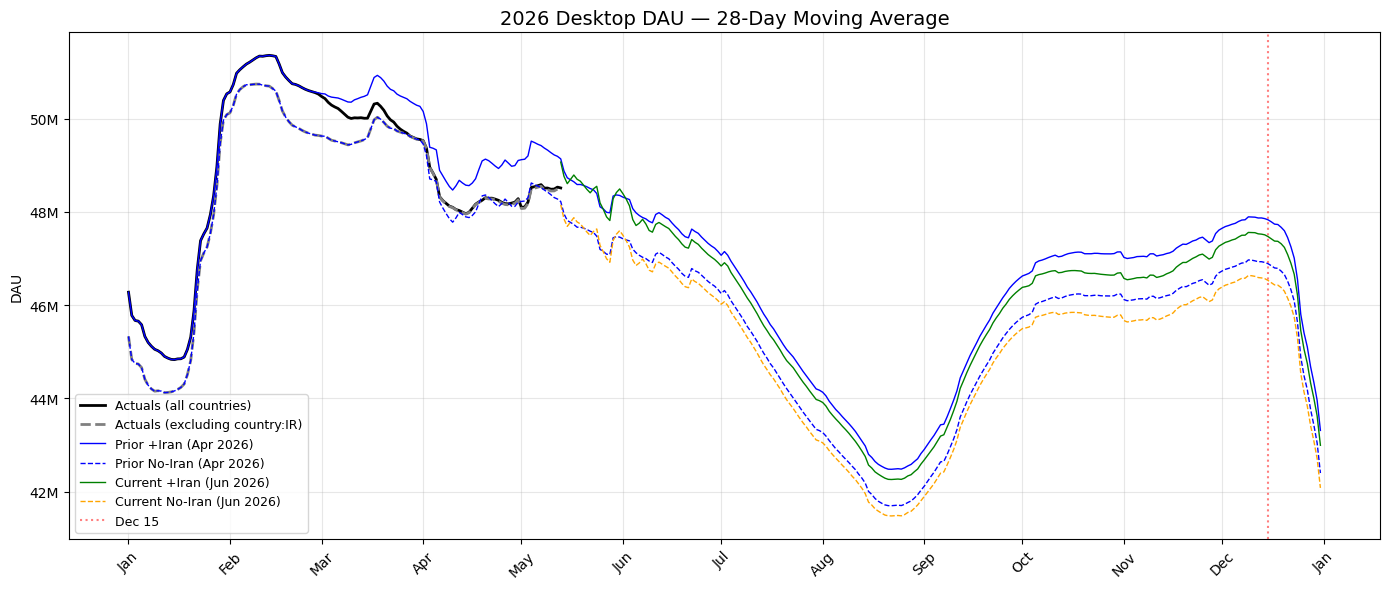

In [8]:
# [plot-desktop]
def clip_display(s):
    """Filter a date-indexed series to the display window."""
    return s[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)].dropna()

def clip_forecast_only(s):
    """Filter to forecast portion only within display window."""
    return s[(s.index >= FORECAST_START) & (s.index <= DISPLAY_END)].dropna()

def millions_formatter(x, pos):
    return f"{x / 1e6:.0f}M"

fig, ax = plt.subplots(figsize=(14, 6))

# Actuals (bold)
ax.plot(clip_display(desktop_actual_all_ma), label="Actuals (all countries)",
        color="black", linewidth=2)
ax.plot(clip_display(desktop_actual_no_iran_ma), label="Actuals (excluding country:IR)",
        color="gray", linewidth=2, linestyle="--")

# Forecasts (thin) — prior (blue) and current (green/orange)
ax.plot(clip_display(prev_desktop_plus_iran_ma), label="Prior +Iran (Apr 2026)",
        color="blue", linewidth=1)
ax.plot(clip_display(prev_desktop_no_iran_ma), label="Prior No-Iran (Apr 2026)",
        color="blue", linewidth=1, linestyle="--")
ax.plot(clip_forecast_only(desktop_plus_iran_ma), label="Current +Iran (Jun 2026)",
        color="green", linewidth=1)
ax.plot(clip_forecast_only(desktop_no_iran_ma), label="Current No-Iran (Jun 2026)",
        color="orange", linewidth=1, linestyle="--")

ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
ax.set_title("2026 Desktop DAU — 28-Day Moving Average", fontsize=14)
ax.set_ylabel("DAU")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc="lower left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [9]:
# [desktop-dec15]
desktop_series = {
    "Actuals (all countries)": desktop_actual_all_ma,
    "Actuals (excl IR)": desktop_actual_no_iran_ma,
    "Prior +Iran (Apr 2026)": prev_desktop_plus_iran_ma,
    "Prior No-Iran (Apr 2026)": prev_desktop_no_iran_ma,
    "Current +Iran (Jun 2026)": desktop_plus_iran_ma,
    "Current No-Iran (Jun 2026)": desktop_no_iran_ma,
}

header = f"{'Series':<28s} {'Dec 15 28-day MA':>18s}"
print(header)
print("-" * len(header))
for name, s in desktop_series.items():
    val = s.get(MEASUREMENT_DATE, np.nan)
    val_str = f"{val:>15,.0f}" if pd.notna(val) else f"{'N/A':>15s}"
    print(f"{name:<28s} {val_str:>18s}")


Series                         Dec 15 28-day MA
-----------------------------------------------
Actuals (all countries)                     N/A
Actuals (excl IR)                           N/A
Prior +Iran (Apr 2026)               47,832,386
Prior No-Iran (Apr 2026)             46,891,136
Current +Iran (Jun 2026)             47,472,435
Current No-Iran (Jun 2026)           46,531,185


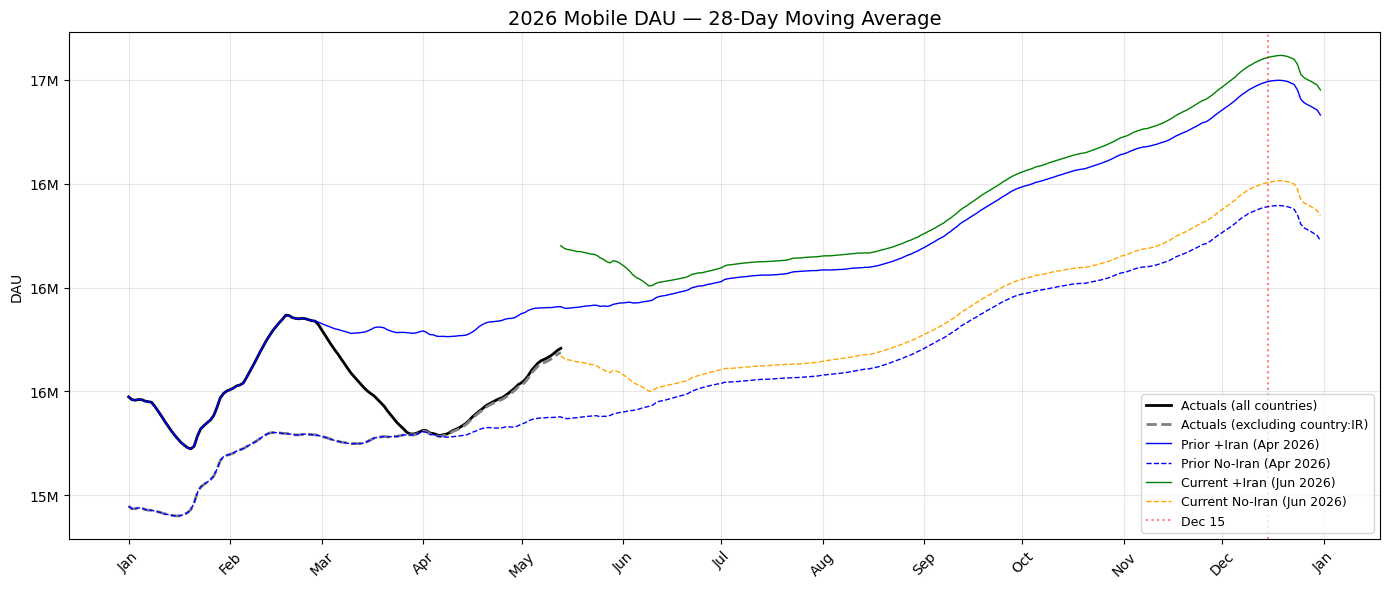

In [10]:
# [plot-mobile]
fig, ax = plt.subplots(figsize=(14, 6))

# Actuals (bold)
ax.plot(clip_display(mobile_actual_all_ma), label="Actuals (all countries)",
        color="black", linewidth=2)
ax.plot(clip_display(mobile_actual_no_iran_ma), label="Actuals (excluding country:IR)",
        color="gray", linewidth=2, linestyle="--")

# Forecasts (thin) — prior (blue) and current (green/orange)
ax.plot(clip_display(prev_mobile_plus_iran_ma), label="Prior +Iran (Apr 2026)",
        color="blue", linewidth=1)
ax.plot(clip_display(prev_mobile_no_iran_ma), label="Prior No-Iran (Apr 2026)",
        color="blue", linewidth=1, linestyle="--")
ax.plot(clip_forecast_only(mobile_plus_iran_ma), label="Current +Iran (Jun 2026)",
        color="green", linewidth=1)
ax.plot(clip_forecast_only(mobile_no_iran_ma), label="Current No-Iran (Jun 2026)",
        color="orange", linewidth=1, linestyle="--")

ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
ax.set_title("2026 Mobile DAU — 28-Day Moving Average", fontsize=14)
ax.set_ylabel("DAU")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc="lower right", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [11]:
# [mobile-dec15]
mobile_series = {
    "Actuals (all countries)": mobile_actual_all_ma,
    "Actuals (excl IR)": mobile_actual_no_iran_ma,
    "Prior +Iran (Apr 2026)": prev_mobile_plus_iran_ma,
    "Prior No-Iran (Apr 2026)": prev_mobile_no_iran_ma,
    "Current +Iran (Jun 2026)": mobile_plus_iran_ma,
    "Current No-Iran (Jun 2026)": mobile_no_iran_ma,
}

header = f"{'Series':<28s} {'Dec 15 28-day MA':>18s}"
print(header)
print("-" * len(header))
for name, s in mobile_series.items():
    val = s.get(MEASUREMENT_DATE, np.nan)
    val_str = f"{val:>15,.0f}" if pd.notna(val) else f"{'N/A':>15s}"
    print(f"{name:<28s} {val_str:>18s}")


Series                         Dec 15 28-day MA
-----------------------------------------------
Actuals (all countries)                     N/A
Actuals (excl IR)                           N/A
Prior +Iran (Apr 2026)               16,991,373
Prior No-Iran (Apr 2026)             16,389,749
Current +Iran (Jun 2026)             17,107,875
Current No-Iran (Jun 2026)           16,506,250


In [22]:
# [export-mobile-plot-csv]
# Export the six series shown in [plot-mobile] to CSV, spanning the union of all series.
mobile_plot_series = {
    "actuals_all": mobile_actual_all_ma,
    "actuals_no_iran": mobile_actual_no_iran_ma,
    "april_plus_iran": prev_mobile_plus_iran_ma,
    "april_no_iran": prev_mobile_no_iran_ma,
    "june_draft_plus_iran": mobile_plus_iran_ma,
    "june_draft_no_iran": mobile_no_iran_ma,
}

union_start = pd.to_datetime('2026-01-01')#min(s.index.min() for s in mobile_plot_series.values())
union_end = max(s.index.max() for s in mobile_plot_series.values())
date_range = pd.date_range(union_start, union_end, freq="D")

mobile_plot_export = pd.DataFrame({"date": date_range})
for col_name, series in mobile_plot_series.items():
    mobile_plot_export[col_name] = series.reindex(date_range).values

mobile_plot_csv_path = "data-official/2026-06/june_mobile_plot_series.adj-h.csv"
mobile_plot_export.to_csv(mobile_plot_csv_path, index=False)
print(f"Wrote {len(mobile_plot_export)} rows to {mobile_plot_csv_path}")
print(f"Date range: {mobile_plot_export['date'].min().date()} to {mobile_plot_export['date'].max().date()}")


Wrote 730 rows to data-official/2026-06/june_mobile_plot_series.adj-h.csv
Date range: 2026-01-01 to 2027-12-31


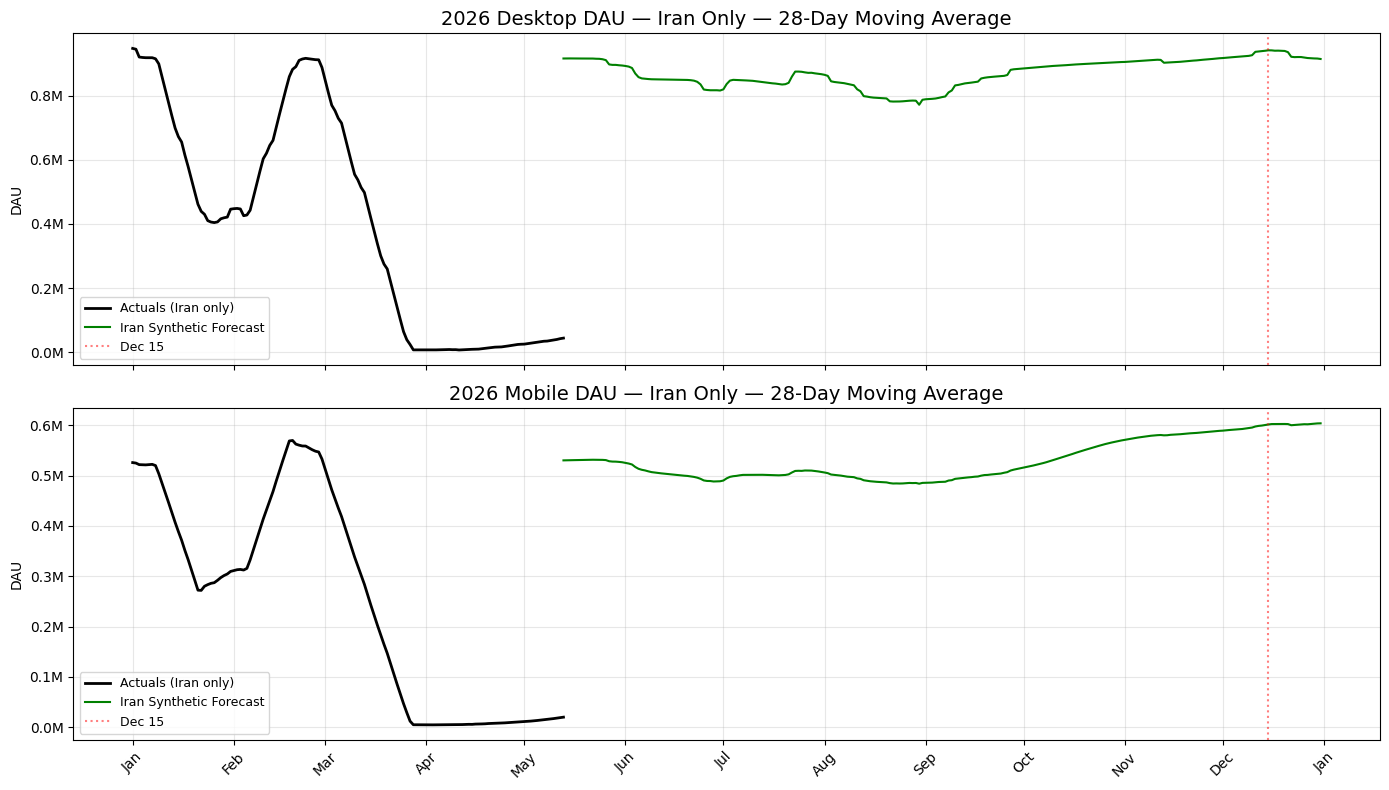

In [13]:
# [plot-iran]
# Load Iran-only synthetic forecasts
IRAN_DESKTOP_PATH = "data-official/iran_synthetic/iran_synthetic.parquet"
IRAN_MOBILE_PATH = "data-official/iran_synthetic/mobile/iran_synthetic.parquet"

def load_iran_synthetic(path, data_source):
    """Load Iran synthetic parquet, return daily DAU series for the given data source."""
    df = pd.read_parquet(path)
    mask = (df["data_source"] == data_source) & (df["metric"] == "DAU")
    result = df.loc[mask, ["target_date", "iran_value"]].copy()
    result["target_date"] = pd.to_datetime(result["target_date"])
    return result.sort_values("target_date").reset_index(drop=True)

desktop_iran_raw = load_iran_synthetic(IRAN_DESKTOP_PATH, "legacy_desktop")
mobile_iran_raw = load_iran_synthetic(IRAN_MOBILE_PATH, "glean_mobile")

desktop_iran_forecast_ma = daily_to_28ma(desktop_iran_raw["target_date"], desktop_iran_raw["iran_value"])
mobile_iran_forecast_ma = daily_to_28ma(mobile_iran_raw["target_date"], mobile_iran_raw["iran_value"])

# Iran actuals = all-countries actuals minus no-Iran actuals
desktop_iran_actual_ma = desktop_actual_all_ma - desktop_actual_no_iran_ma
mobile_iran_actual_ma = mobile_actual_all_ma - mobile_actual_no_iran_ma

def millions_formatter_1dp(x, pos):
    return f"{x / 1e6:.1f}M"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- Desktop Iran ---
ax1.plot(clip_display(desktop_iran_actual_ma), label="Actuals (Iran only)",
         color="black", linewidth=2)
ax1.plot(clip_forecast_only(desktop_iran_forecast_ma), label="Iran Synthetic Forecast",
         color="green", linewidth=1.5)
ax1.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
ax1.set_title("2026 Desktop DAU — Iran Only — 28-Day Moving Average", fontsize=14)
ax1.set_ylabel("DAU")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter_1dp))
ax1.legend(loc="best", fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Mobile Iran ---
ax2.plot(clip_display(mobile_iran_actual_ma), label="Actuals (Iran only)",
         color="black", linewidth=2)
ax2.plot(clip_forecast_only(mobile_iran_forecast_ma), label="Iran Synthetic Forecast",
         color="green", linewidth=1.5)
ax2.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
ax2.set_title("2026 Mobile DAU — Iran Only — 28-Day Moving Average", fontsize=14)
ax2.set_ylabel("DAU")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter_1dp))
ax2.legend(loc="best", fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [14]:
# [iran-values]
for label, ma in [("Desktop", desktop_iran_forecast_ma), ("Mobile", mobile_iran_forecast_ma)]:
    apr10 = ma.get(pd.Timestamp("2026-04-10"), float("nan"))
    may15 = ma.get(pd.Timestamp("2026-05-15"), float("nan"))
    print(f"{label} Iran forecast (28-day MA):")
    print(f"  Apr 10: {apr10:,.0f}")
    print(f"  May 15: {may15:,.0f}")
    print()


Desktop Iran forecast (28-day MA):
  Apr 10: 689,045
  May 15: 915,942

Mobile Iran forecast (28-day MA):
  Apr 10: 482,991
  May 15: 530,643



In [15]:
# [export-csv]
# Build a CSV with the four 28-day MA forecast series (all with headwinds applied)
export_end = pd.Timestamp("2026-12-31")
date_range = pd.date_range(FORECAST_START, export_end, freq="D")

export_df = pd.DataFrame({
    "date": date_range,
    "desktop_28ma_with_iran": desktop_plus_iran_ma.reindex(date_range).values,
    "desktop_28ma_no_iran": desktop_no_iran_ma.reindex(date_range).values,
    "mobile_28ma_with_iran": mobile_plus_iran_ma.reindex(date_range).values,
    "mobile_28ma_no_iran": mobile_no_iran_ma.reindex(date_range).values,
})

csv_path = "data-official/2026-06/june_composite_forecast_28ma.adj-h.csv"
export_df.to_csv(csv_path, index=False)
print(f"Wrote {len(export_df)} rows to {csv_path}")
print(f"Date range: {export_df['date'].min().date()} to {export_df['date'].max().date()}")
print(f"\nDec 15 values:")
dec15 = export_df[export_df["date"] == "2026-12-15"].iloc[0]
for col in export_df.columns[1:]:
    print(f"  {col}: {dec15[col]:,.0f}")


Wrote 233 rows to data-official/2026-06/june_composite_forecast_28ma.adj-h.csv
Date range: 2026-05-13 to 2026-12-31

Dec 15 values:
  desktop_28ma_with_iran: 47,472,435
  desktop_28ma_no_iran: 46,531,185
  mobile_28ma_with_iran: 17,107,875
  mobile_28ma_no_iran: 16,506,250


Read 275 rows: 2026-04-01 to 2026-12-31


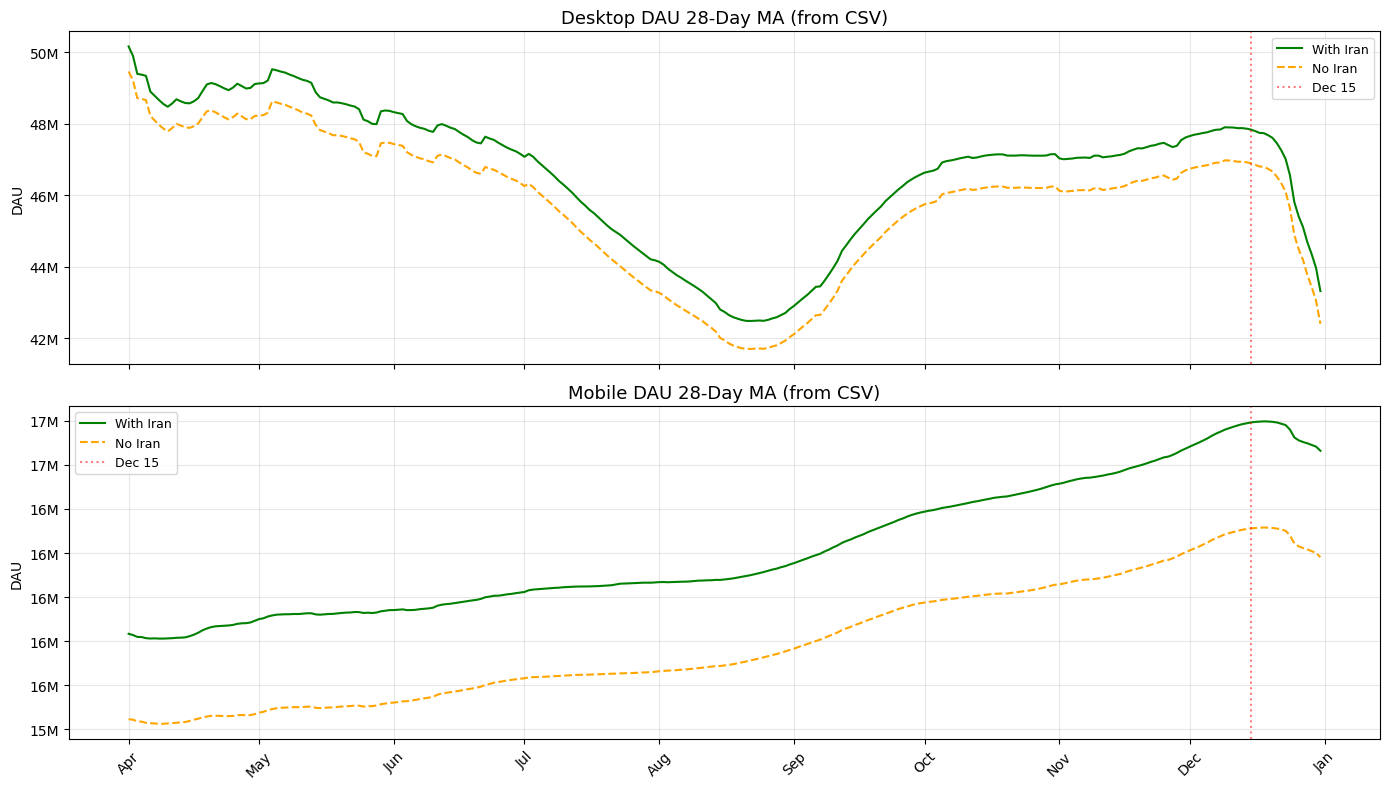

In [16]:
# [verify-csv]

def clip_display(s):
    """Filter a date-indexed series to the display window."""
    return s[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)].dropna()

def clip_forecast_only(s):
    """Filter to forecast portion only (starting Apr 1) within display window."""
    return s[(s.index >= FORECAST_START) & (s.index <= DISPLAY_END)].dropna()

def millions_formatter(x, pos):
    return f"{x / 1e6:.0f}M"

# Independent read-back of the exported CSV to verify correctness
verify_df = pd.read_csv("april_composite_forecast_28ma.adj-h.csv", parse_dates=["date"])
print(f"Read {len(verify_df)} rows: {verify_df['date'].min().date()} to {verify_df['date'].max().date()}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Desktop
ax1.plot(verify_df["date"], verify_df["desktop_28ma_with_iran"], label="With Iran", color="green")
ax1.plot(verify_df["date"], verify_df["desktop_28ma_no_iran"], label="No Iran", color="orange", linestyle="--")
ax1.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
ax1.set_title("Desktop DAU 28-Day MA (from CSV)", fontsize=13)
ax1.set_ylabel("DAU")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Mobile
ax2.plot(verify_df["date"], verify_df["mobile_28ma_with_iran"], label="With Iran", color="green")
ax2.plot(verify_df["date"], verify_df["mobile_28ma_no_iran"], label="No Iran", color="orange", linestyle="--")
ax2.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
ax2.set_title("Mobile DAU 28-Day MA (from CSV)", fontsize=13)
ax2.set_ylabel("DAU")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()


In [17]:
# [country-data]
import sys, time

# --- Date range for comparison: past 2 weeks ending yesterday ---
COMPARE_END = pd.Timestamp.now().normalize() - pd.Timedelta(days=1)
COMPARE_START = COMPARE_END - pd.Timedelta(days=13)  # 14 days total
print(f"Comparison period: {COMPARE_START.date()} to {COMPARE_END.date()}")

# --- Countries from the no-Iran forecast (excluding ALL) ---
NAMED_COUNTRIES = ['AR', 'BR', 'CA', 'CN', 'DE', 'FR', 'ID', 'IN', 'IT', 'JP', 'MX', 'PL', 'RU', 'US']

# --- Load country-level forecast DAU from parquets ---
def load_country_forecast(path, data_source, segment_filter, app_filter):
    """Load per-country daily DAU forecasts from a parquet file."""
    df = pd.read_parquet(path)
    mask = (
        (df["country"] != "ALL")
        & (df["segment"] == segment_filter)
        & (df["data_source"] == data_source)
        & (df["app_name"] == app_filter)
        # Include training rows so comparison works before the forecast start date
        & (df["data_type"].isin(["forecast", "training"]))
        & (pd.to_datetime(df["target_date"]) >= COMPARE_START)
        & (pd.to_datetime(df["target_date"]) <= COMPARE_END)
    )
    result = df.loc[mask, ["target_date", "country", "dau"]].copy()
    result["target_date"] = pd.to_datetime(result["target_date"])
    return result.sort_values(["country", "target_date"]).reset_index(drop=True)

desktop_forecast_by_country = load_country_forecast(
    DESKTOP_NO_IRAN_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop"
)
mobile_forecast_by_country = load_country_forecast(
    MOBILE_NO_IRAN_PATH, "glean_mobile", "{}", "ALL MOBILE"
)
print(f"Desktop forecast: {len(desktop_forecast_by_country)} rows, "
      f"{sorted(desktop_forecast_by_country['country'].unique())}")
print(f"Mobile forecast:  {len(mobile_forecast_by_country)} rows, "
      f"{sorted(mobile_forecast_by_country['country'].unique())}")

# --- Query BQ for country-level actuals ---
named_list = ", ".join(f"'{c}'" for c in NAMED_COUNTRIES)
compare_start_str = COMPARE_START.strftime("%Y-%m-%d")
compare_end_str = COMPARE_END.strftime("%Y-%m-%d")

country_queries = {
    "desktop_named": f"""
        SELECT submission_date AS date, country, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
        WHERE app_name = "Firefox Desktop"
          AND submission_date BETWEEN '{compare_start_str}' AND '{compare_end_str}'
          AND country IN ({named_list})
        GROUP BY submission_date, country ORDER BY country, 1
    """,
    "desktop_row": f"""
        SELECT submission_date AS date, 'ROW' AS country, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
        WHERE app_name = "Firefox Desktop"
          AND submission_date BETWEEN '{compare_start_str}' AND '{compare_end_str}'
          AND country NOT IN ({named_list}, 'IR')
        GROUP BY submission_date ORDER BY 1
    """,
    "mobile_named": f"""
        SELECT submission_date AS date, country, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.glean_telemetry.active_users_aggregates`
        WHERE app_name IN ("Fenix", "Firefox iOS", "Focus Android", "Focus iOS")
          AND submission_date BETWEEN '{compare_start_str}' AND '{compare_end_str}'
          AND country IN ({named_list})
        GROUP BY submission_date, country ORDER BY country, 1
    """,
    "mobile_row": f"""
        SELECT submission_date AS date, 'ROW' AS country, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.glean_telemetry.active_users_aggregates`
        WHERE app_name IN ("Fenix", "Firefox iOS", "Focus Android", "Focus iOS")
          AND submission_date BETWEEN '{compare_start_str}' AND '{compare_end_str}'
          AND country NOT IN ({named_list}, 'IR')
        GROUP BY submission_date ORDER BY 1
    """,
}

bq_country_actuals = {}
t0 = time.time()
for i, (name, sql) in enumerate(country_queries.items(), 1):
    sys.stdout.write(f"[{i}/{len(country_queries)}] {name}...")
    sys.stdout.flush()
    df = client.query(sql).to_dataframe()
    df["date"] = pd.to_datetime(df["date"])
    bq_country_actuals[name] = df
    sys.stdout.write(f" {len(df)} rows ({time.time() - t0:.1f}s elapsed)\n")
    sys.stdout.flush()

desktop_actuals_by_country = pd.concat(
    [bq_country_actuals["desktop_named"], bq_country_actuals["desktop_row"]]
).reset_index(drop=True)
mobile_actuals_by_country = pd.concat(
    [bq_country_actuals["mobile_named"], bq_country_actuals["mobile_row"]]
).reset_index(drop=True)

print(f"\nDesktop actuals: {len(desktop_actuals_by_country)} rows")
print(f"Mobile actuals:  {len(mobile_actuals_by_country)} rows")


Comparison period: 2026-05-01 to 2026-05-14
Desktop forecast: 210 rows, ['AR', 'BR', 'CA', 'CN', 'DE', 'FR', 'ID', 'IN', 'IT', 'JP', 'MX', 'PL', 'ROW', 'RU', 'US']
Mobile forecast:  210 rows, ['AR', 'BR', 'CA', 'CN', 'DE', 'FR', 'ID', 'IN', 'IT', 'JP', 'MX', 'PL', 'ROW', 'RU', 'US']
[1/4] desktop_named... 182 rows (4.5s elapsed)
[2/4] desktop_row... 13 rows (8.6s elapsed)
[3/4] mobile_named... 182 rows (12.1s elapsed)
[4/4] mobile_row... 13 rows (52.0s elapsed)

Desktop actuals: 195 rows
Mobile actuals:  195 rows


In [18]:
# [country-summary]
TABLE_START = COMPARE_START
TABLE_END = COMPARE_END

def build_country_summary(forecast_df, actuals_df):
    """Build a text summary table comparing actual vs forecast DAU per country."""
    rows = []
    for country in sorted(forecast_df["country"].unique()):
        fc = forecast_df[forecast_df["country"] == country]
        fc = fc[(fc["target_date"] >= TABLE_START) & (fc["target_date"] <= TABLE_END)]
        fc = fc.set_index("target_date")["dau"]

        ac = actuals_df[actuals_df["country"] == country]
        ac = ac[(ac["date"] >= TABLE_START) & (ac["date"] <= TABLE_END)]
        ac = ac.set_index("date")["dau"]

        overlap = ac.index.intersection(fc.index)
        if len(overlap) == 0:
            continue
        n_days = len(overlap)
        actual_total = ac.loc[overlap].sum()
        forecast_total = fc.loc[overlap].sum()
        diff = forecast_total - actual_total
        avg_diff = diff / n_days
        actual_avg = actual_total / n_days
        error_pct = avg_diff / actual_avg * 100
        rows.append({
            "country": country,
            "actual_total": actual_total,
            "forecast_total": forecast_total,
            "diff": diff,
            "avg_diff": avg_diff,
            "error_pct": error_pct,
        })
    summary = pd.DataFrame(rows).sort_values("actual_total", ascending=False)

    # Render as aligned text
    lines = []
    header = f"{'Country':>9}  {'Actual':>14}  {'Forecast':>14}  {'Diff':>14}  {'Avg Diff':>12}  {'Error':>7}"
    lines.append(header)
    lines.append("-" * len(header))
    for _, r in summary.iterrows():
        lines.append(
            f"{r['country']:>9}  {r['actual_total']:>14,.0f}  {r['forecast_total']:>14,.0f}"
            f"  {r['diff']:>+14,.0f}  {r['avg_diff']:>+12,.0f}  {r['error_pct']:>+6.1f}%"
        )
    return "\n".join(lines)

print(f"Desktop (Legacy) — Country Comparison  [{TABLE_START.date()} to {TABLE_END.date()}]")
print("=" * 80)
print(build_country_summary(desktop_forecast_by_country, desktop_actuals_by_country))

print(f"\nMobile (Glean) — Country Comparison  [{TABLE_START.date()} to {TABLE_END.date()}]")
print("=" * 80)
print(build_country_summary(mobile_forecast_by_country, mobile_actuals_by_country))


Desktop (Legacy) — Country Comparison  [2026-05-01 to 2026-05-14]
  Country          Actual        Forecast            Diff      Avg Diff    Error
--------------------------------------------------------------------------------
      ROW     210,213,684     209,311,889        -901,795       -69,369    -0.4%
       US      94,478,978      94,318,958        -160,020       -12,309    -0.2%
       DE      70,768,622      70,631,377        -137,245       -10,557    -0.2%
       FR      44,925,408      44,798,637        -126,771        -9,752    -0.3%
       IN      32,663,975      32,529,936        -134,039       -10,311    -0.4%
       PL      25,822,459      25,744,212         -78,247        -6,019    -0.3%
       BR      24,650,803      24,451,661        -199,142       -15,319    -0.8%
       ID      19,380,363      19,239,918        -140,445       -10,803    -0.7%
       IT      17,505,990      17,420,035         -85,955        -6,612    -0.5%
       RU      16,631,575      16,594,418  

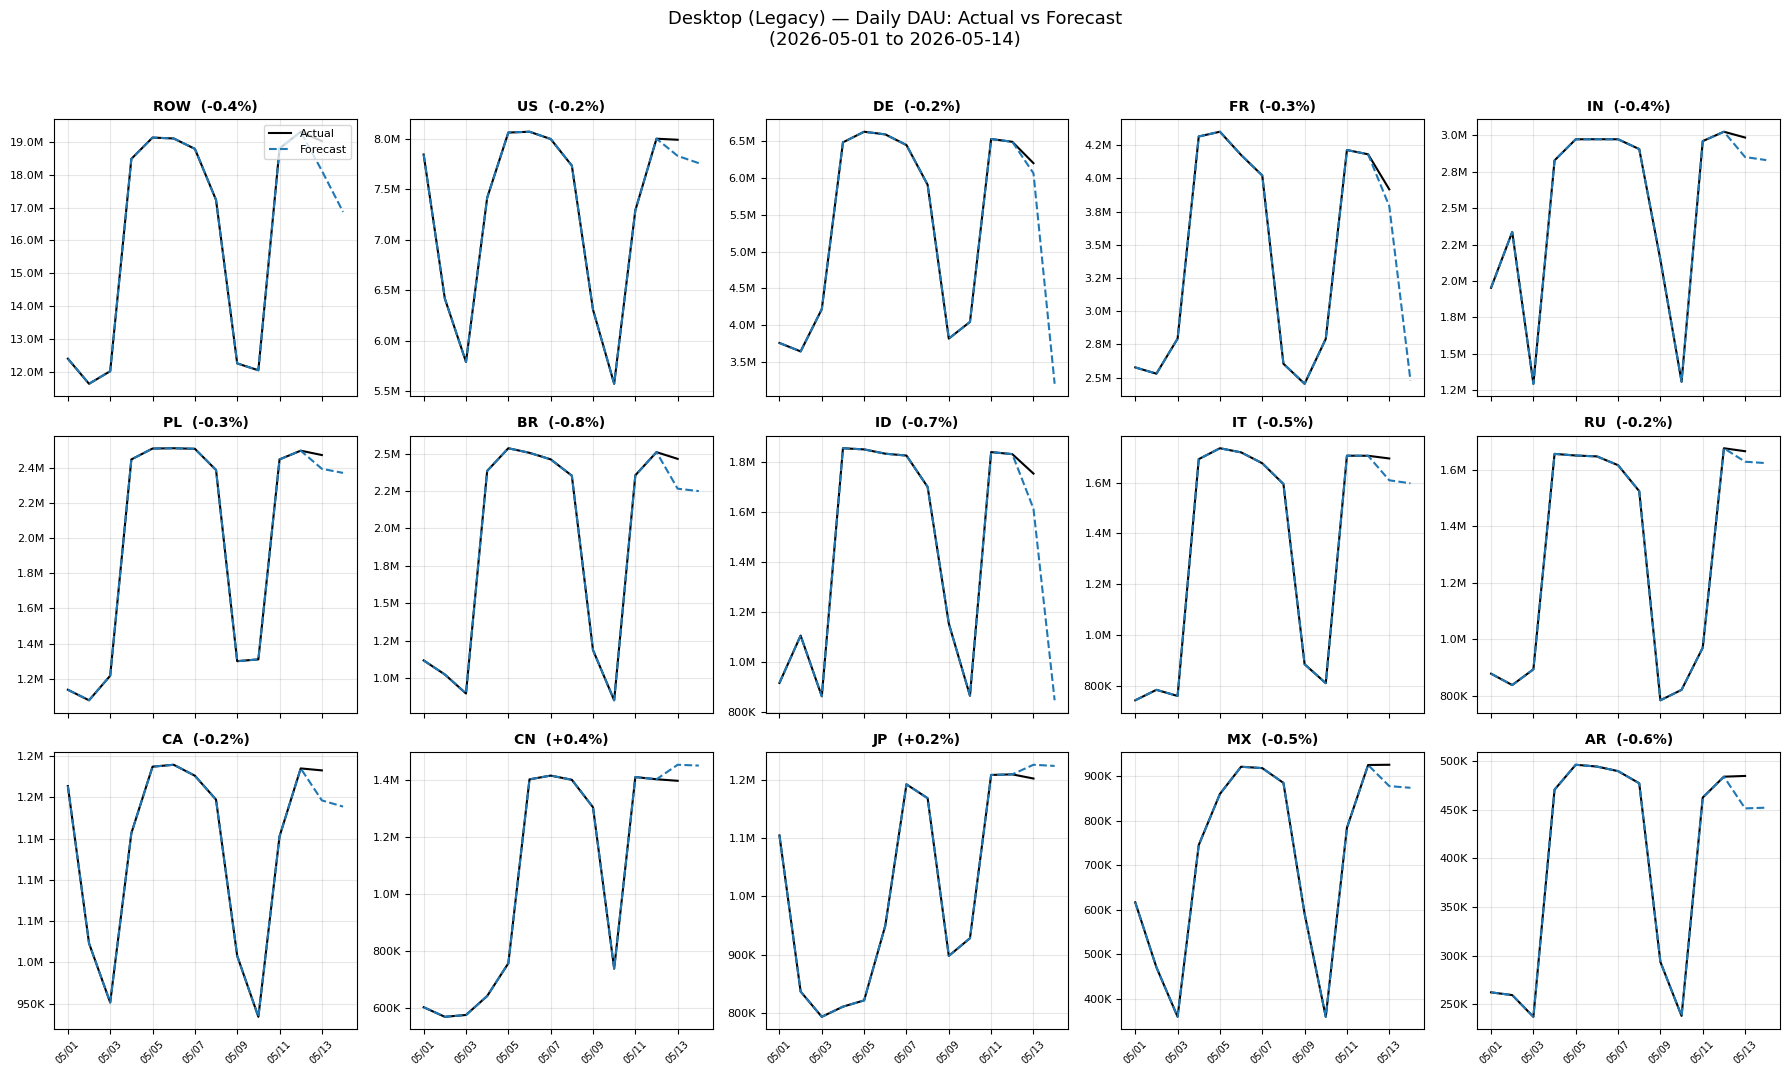

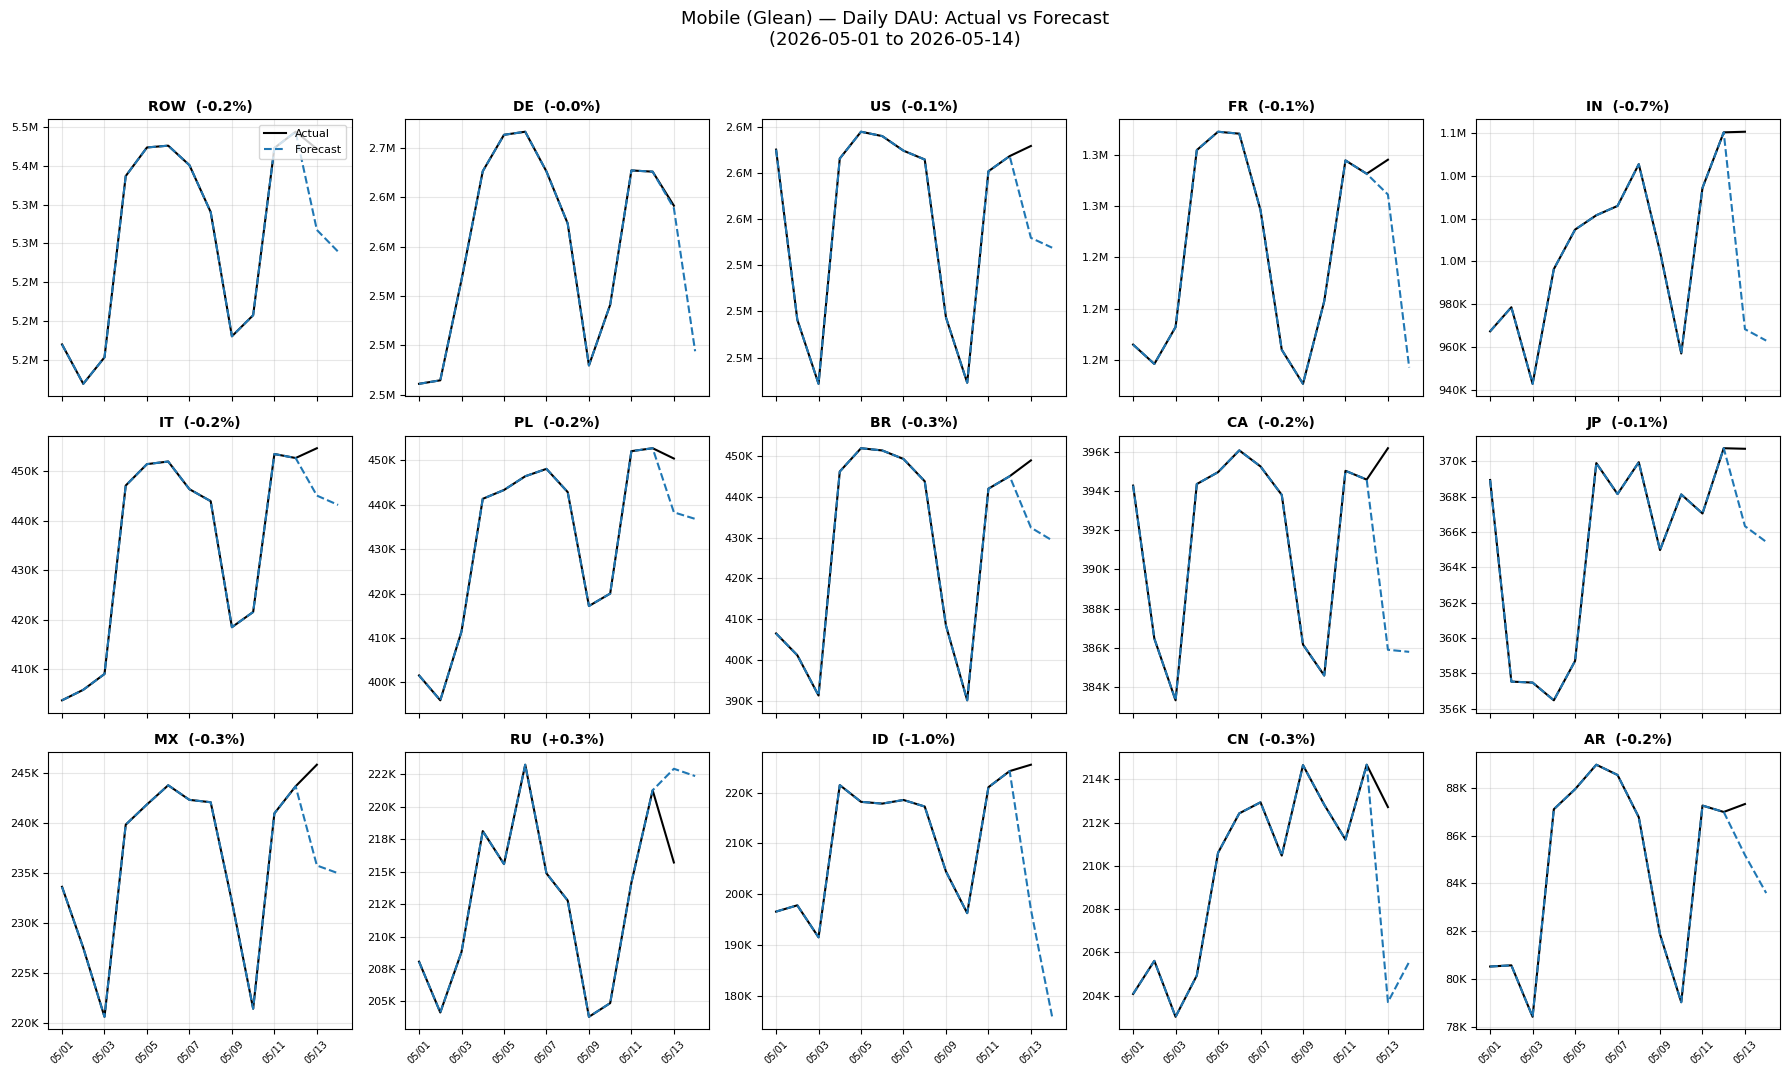

In [19]:
# [country-plots]
def plot_country_grid(forecast_df, actuals_df, platform_name, countries):
    """Plot a grid of actual vs forecast daily DAU, one subplot per country."""
    ncols = 5
    nrows = (len(countries) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.5 * nrows), sharex=True)
    axes = axes.flatten()

    for i, country in enumerate(countries):
        ax = axes[i]
        fc = forecast_df[forecast_df["country"] == country].set_index("target_date")["dau"].sort_index()
        ac = actuals_df[actuals_df["country"] == country].set_index("date")["dau"].sort_index()

        ax.plot(ac.index, ac.values, label="Actual", color="black", linewidth=1.5)
        ax.plot(fc.index, fc.values, label="Forecast", color="tab:blue", linewidth=1.5, linestyle="--")

        # Annotate with mean % error
        overlap = ac.index.intersection(fc.index)
        if len(overlap) > 0:
            actual_mean = ac.loc[overlap].mean()
            forecast_mean = fc.loc[overlap].mean()
            pct_err = (forecast_mean - actual_mean) / actual_mean * 100
            ax.set_title(f"{country}  ({pct_err:+.1f}%)", fontsize=10, fontweight="bold")
        else:
            ax.set_title(country, fontsize=10, fontweight="bold")

        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"{x / 1e6:.1f}M" if abs(x) >= 1e6 else f"{x / 1e3:.0f}K")
        )
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.tick_params(axis="y", labelsize=8)
        ax.grid(alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8, loc="upper right")

    for j in range(len(countries), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(
        f"{platform_name} — Daily DAU: Actual vs Forecast\n({COMPARE_START.date()} to {COMPARE_END.date()})",
        fontsize=13, y=1.02,
    )
    fig.tight_layout()
    plt.show()


# Sort countries by average actual DAU (largest first)
desktop_country_order = (
    desktop_actuals_by_country.groupby("country")["dau"].mean()
    .sort_values(ascending=False).index.tolist()
)
mobile_country_order = (
    mobile_actuals_by_country.groupby("country")["dau"].mean()
    .sort_values(ascending=False).index.tolist()
)

plot_country_grid(
    desktop_forecast_by_country, desktop_actuals_by_country,
    "Desktop (Legacy)", desktop_country_order,
)
plot_country_grid(
    mobile_forecast_by_country, mobile_actuals_by_country,
    "Mobile (Glean)", mobile_country_order,
)
